In [1]:
import os
import sys
from datetime import datetime
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fooof import FOOOF
import syncopy as spy
import json

# custom path for parse_logfile
sys.path.insert(1, '/mnt/cs/projects/MWzeronoise/Analysis/4Shivangi/code/functions/unreal_logfile')
from parse_logfile import TextLog  # noqa: E402


Syncopy 2023.9

See https://syncopy.org for the online documentation.
For bug reports etc. please send an email to syncopy@esi-frankfurt.de



/gs/home/patels/.conda/envs/warping/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Logging to log directory '/cs/home/patels/.spy/logs'.
Temporary storage directory set to '/cs/home/patels/.spy/tmp_storage'.



In [2]:
# -----------------------------
# User Config
# -----------------------------
lfp_data_dir = '/cs/projects/MWzeronoise/Analysis/4Shivangi/Datasets/neural_data/stimAalign_cut/clean_full_length'
trial_info_dir = '/cs/projects/MWzeronoise/Analysis/4Shivangi/Datasets/neural_data/stimAalign_cut/full_length'
states_data_dir = '/cs/projects/MWzeronoise/Analysis/4Shivangi/Datasets/states_analysis'
output_dir = '/cs/projects/MWzeronoise/Analysis/4Shivangi/plots/states_lfp/all_trials/200_600/erp_spectra'
results_dir = '/mnt/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/states_analysis/states_lfp'
results_data_dir = os.path.join(results_dir, "200_600", "all_trials")

In [3]:
os.makedirs(output_dir, exist_ok=True)
os.makedirs(results_data_dir, exist_ok=True)
colors = [(0.55, 0.0, 0.55), (0.0, 0.39, 0.39), (0.8, 0.33, 0.0)]

sessions = ['20230203', '20230208', '20230209', '20230213', '20230214']
N_STATES_TO_USE = 4
n_perms = 1000
alpha = 0.05
rng = np.random.default_rng(42)

# load states info for all sessions
state_probs = np.load(f'{states_data_dir}/foraging_shivangi_no_sess1_clipped_state_probs.npy')
with open(f'{states_data_dir}/foraging_shivangi_no_sess1_clipped_session_index.json') as f:
    session_index = json.load(f)

session_to_probs = {}
for sess in session_index:
    session_id = sess['session_id']
    session_date = session_id.split('_')[1]
    session_to_probs[session_date] = state_probs[
        sess['start_idx']: sess['end_idx'] + 1
    ]

In [4]:
session_to_probs['20230214']

array([[0.4695, 0.0309, 0.4993, 0.0003],
       [0.4002, 0.0303, 0.5696, 0.    ],
       [0.3331, 0.0293, 0.6376, 0.    ],
       ...,
       [0.1959, 0.0123, 0.7904, 0.0013],
       [0.225 , 0.0103, 0.7647, 0.    ],
       [0.2601, 0.0097, 0.7297, 0.0005]])

In [ ]:
# -----------------------------
# Helper functions
# -----------------------------
def remove_nan_trials_channels(datas):
    trial_mask = [not np.all(np.isnan(tr)) for tr in datas.trials]
    if not any(trial_mask):
        return None, []
    cfg = spy.StructDict(trials=np.where(trial_mask)[0])
    datas_clean = spy.selectdata(cfg, datas)
    trial_stack = np.stack(datas_clean.trials, axis=0)
    valid_ch_idx = np.where(~np.all(np.isnan(trial_stack), axis=(0, 1)))[0]
    if len(valid_ch_idx) == 0:
        return None, []
    cfg = spy.StructDict(channel=valid_ch_idx)
    datas_clean = spy.selectdata(cfg, datas_clean)
    valid_channels = [datas.channel[i] for i in valid_ch_idx]
    return datas_clean, valid_channels

def extract_power_trials(freq_analysis):
    try:
        freqs = getattr(freq_analysis, 'freq', None)
        channels = getattr(freq_analysis, 'channel', None)
        candidate = np.squeeze(freq_analysis.trials)
        if candidate.ndim == 3:
            return candidate, freqs, channels
        if candidate.ndim == 2 and freqs is not None and channels is not None:
            if candidate.shape[1] == len(freqs) * len(channels):
                reshaped = candidate.reshape((candidate.shape[0], len(freqs), len(channels)))
                return reshaped, freqs, channels
        return None, None, None
    except Exception as e:
        print("extract_power_trials error:", e)
        return None, None, None

def ensure_trialindex_in_trialdefinition(datalfp):
    if datalfp.trialdefinition.shape[1] < 4:
        nTrials = datalfp.trialdefinition.shape[0]
        datalfp.trialdefinition = np.hstack(
            (datalfp.trialdefinition, np.arange(nTrials).reshape(-1, 1))
        )


# Compare overlapping trials in the states

In [12]:
def get_state_bins(state_probs, threshold=0.25, n_states=4):
    """
    Create binary masks for trials belonging to each state bin.
    
    Parameters:
    -----------
    state_probs : ndarray (n_trials, n_states)
        State probability matrix
    threshold : float
        Minimum probability for trial to be included in state bin
    n_states : int
        Number of states to consider
        
    Returns:
    --------
    state_bins : dict
        Dictionary with keys 0 to n_states-1, values are boolean arrays
    """
    state_bins = {}
    for state_idx in range(min(n_states, state_probs.shape[1])):
        state_bins[state_idx] = state_probs[:, state_idx] > threshold
    
    return state_bins

PROB_THRESHOLD = 0.25

# ----------------------------- 
# Main data collection 
# ----------------------------- 
state_data_timelock = {}
state_data_spectra = {}
state_data_residuals = {}

for session_name in sessions[0:]:
    print(f"\n=== Processing session {session_name} ===")
    
    lfp_path = os.path.join(lfp_data_dir, session_name, 'Cleaned_lfp_FT.spy')
    trial_info_path = os.path.join(trial_info_dir, session_name, 'Trial_Info.pkl')
    
    if not os.path.exists(lfp_path) or not os.path.exists(trial_info_path):
        continue
    
    # Get state probabilities for this session
    predicted_state_probs = session_to_probs[session_name]
    
    # Load trial info
    trial_info_df = pd.read_pickle(trial_info_path)
    trial_info_df.iloc[:, 0] = (trial_info_df.iloc[:, 0] - 1000).astype('Int64')
    
    # Create dataframe with state probabilities for each state
    stim_df = pd.DataFrame({'TrialIndex': np.arange(len(predicted_state_probs))})
    for state_idx in range(N_STATES_TO_USE):
        stim_df[f'State{state_idx}_prob'] = predicted_state_probs[:, state_idx]
    
    # Merge with trial info
    combined_df = pd.merge(
        trial_info_df, 
        stim_df, 
        left_on='Trial_Number', 
        right_on='TrialIndex', 
        how='inner'
    )
    
    # Load LFP data
    datalfp = spy.load(lfp_path)
    ensure_trialindex_in_trialdefinition(datalfp)
    
    cfg = spy.StructDict(latency=[-0.2, 0.6])
    data = spy.selectdata(cfg, datalfp)
    
    selected_trials = data.trialdefinition[:, 3].astype(int)
    states_trial_info_filt = combined_df[combined_df['TrialIndex'].isin(selected_trials)]
    
    # Create state bins based on probability threshold
    state_probs_array = states_trial_info_filt[[f'State{i}_prob' for i in range(N_STATES_TO_USE)]].to_numpy()
    state_bins = get_state_bins(state_probs_array, threshold=PROB_THRESHOLD, n_states=N_STATES_TO_USE)
    
    # Print statistics for this session
    print(f"\nSession {session_name} - Trial counts per state bin (>{PROB_THRESHOLD*100}% probability):")
    for state_idx in range(N_STATES_TO_USE):
        n_trials = np.sum(state_bins[state_idx])
        print(f"  State {state_idx}: {n_trials} trials ({n_trials/len(state_bins[state_idx])*100:.1f}%)")
    
    # Check for overlap between bins
    overlap_matrix = np.zeros((N_STATES_TO_USE, N_STATES_TO_USE))
    for i in range(N_STATES_TO_USE):
        for j in range(i+1, N_STATES_TO_USE):
            overlap = np.sum(state_bins[i] & state_bins[j])
            overlap_matrix[i, j] = overlap
            if overlap > 0:
                print(f"  Overlap State {i} & State {j}: {overlap} trials")
    
    # Process each state bin
    for state_idx in range(N_STATES_TO_USE):
        if np.sum(state_bins[state_idx]) == 0:
            print(f"  Skipping State {state_idx}: no trials above threshold")
            continue
        
        # Select trials for this state bin
        trial_indices = np.where(state_bins[state_idx])[0]
        cfg_sel = spy.StructDict(trials=trial_indices)
        datas_state = spy.selectdata(cfg_sel, data)
        
        datas_state_clean, valid_channels = remove_nan_trials_channels(datas_state)
        if datas_state_clean is None:
            continue
        
        # --- Timelock trials ---
        trials_array = np.stack(datas_state_clean.trials, axis=0)
        time_vec = datas_state_clean.time[0]
        
        # Store timelock data
        key = (session_name, state_idx)
        if key not in state_data_timelock:
            state_data_timelock[key] = []
        state_data_timelock[key].append({
            'trials': trials_array,
            'time': time_vec,
            'channels': valid_channels,
            'n_trials': len(trial_indices)
        })
        
        # --- Spectra ---
        cfg_low = spy.StructDict(
            method='mtmfft', 
            foilim=[2, 30], 
            out='pow', 
            keeptrials=True, 
            taper='hann'
        )
        freq_low = spy.freqanalysis(datas_state_clean, cfg_low)
        low_power, freqs_low, channels_low = extract_power_trials(freq_low)
        
        cfg_high = spy.StructDict(
            method='mtmfft', 
            foilim=[30, 100], 
            out='pow', 
            keeptrials=True, 
            tapsmofrq=4
        )
        freq_high = spy.freqanalysis(datas_state_clean, cfg_high)
        high_power, freqs_high, channels_high = extract_power_trials(freq_high)
        
        if low_power is None or high_power is None:
            continue
        
        power_trials = np.concatenate((low_power, high_power), axis=1)
        freqs_combined = np.concatenate((freqs_low, freqs_high))
        
        # Store spectra data
        if key not in state_data_spectra:
            state_data_spectra[key] = []
        state_data_spectra[key].append({
            'power': power_trials,
            'freqs': freqs_combined,
            'channels': valid_channels,
            'n_trials': len(trial_indices)
        })
        
        # --- FOOOF on mean spectrum per channel ---
        mean_spec = np.nanmean(power_trials, axis=0)
        resid_session = np.full_like(mean_spec, np.nan)
        freq_res = np.median(np.diff(freqs_combined))
        
        for ch_i, ch_name in enumerate(valid_channels):
            try:
                fm = FOOOF(
                    peak_width_limits=[max(2 * freq_res, 1.0), 12],
                    max_n_peaks=6,
                    min_peak_height=0.05,
                    peak_threshold=1.5,
                    aperiodic_mode='fixed'
                )
                fm.fit(freqs_combined, mean_spec[:, ch_i])
                resid_session[:, ch_i] = fm._spectrum_flat
            except Exception as e:
                print(f"FOOOF failed {session_name}, State {state_idx}, ch {ch_name}: {e}")
        
        # Store residuals data
        if key not in state_data_residuals:
            state_data_residuals[key] = []
        state_data_residuals[key].append({
            'residuals': resid_session,
            'freqs': freqs_combined,
            'channels': valid_channels,
            'n_trials': len(trial_indices)
        })


=== Processing session 20230203 ===

Session 20230203 - Trial counts per state bin (>25.0% probability):
  State 0: 968 trials (85.6%)
  State 1: 60 trials (5.3%)
  State 2: 886 trials (78.3%)
  State 3: 23 trials (2.0%)
  Overlap State 0 & State 1: 60 trials
  Overlap State 0 & State 2: 743 trials
  Overlap State 1 & State 2: 6 trials
  Overlap State 2 & State 3: 3 trials

=== Processing session 20230208 ===

Session 20230208 - Trial counts per state bin (>25.0% probability):
  State 0: 677 trials (70.7%)
  State 1: 33 trials (3.4%)
  State 2: 850 trials (88.7%)
  State 3: 34 trials (3.5%)
  Overlap State 0 & State 1: 33 trials
  Overlap State 0 & State 2: 596 trials
  Overlap State 1 & State 2: 15 trials
  Overlap State 2 & State 3: 7 trials

=== Processing session 20230209 ===

Session 20230209 - Trial counts per state bin (>25.0% probability):
  State 0: 802 trials (83.4%)
  State 1: 62 trials (6.4%)
  State 2: 780 trials (81.1%)
  State 3: 11 trials (1.1%)
  Overlap State 0 & Sta


=== Plotting grand averages across sessions & channels ===


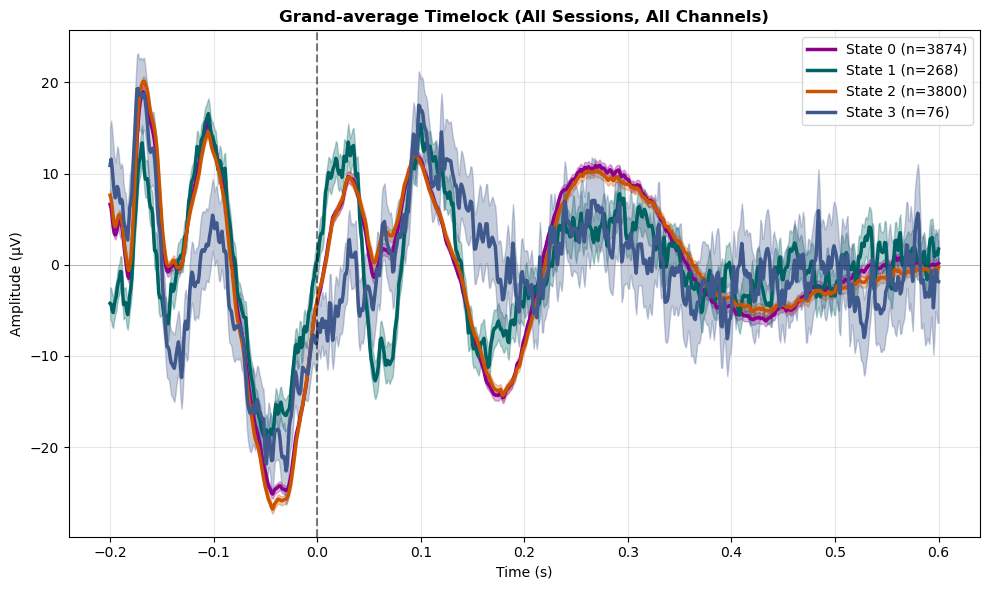

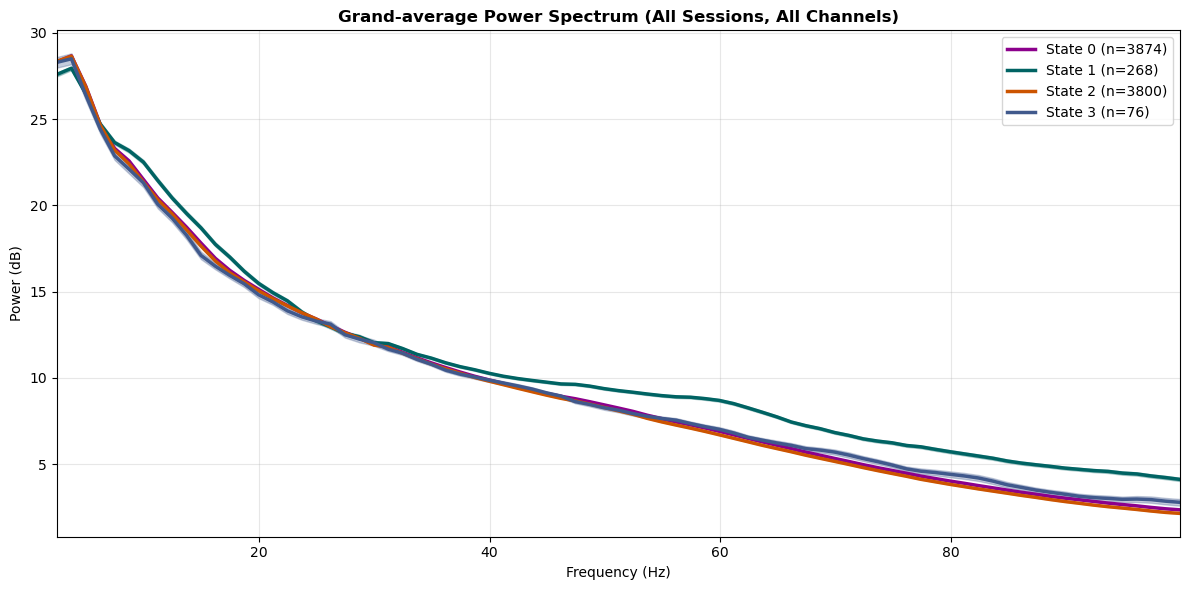

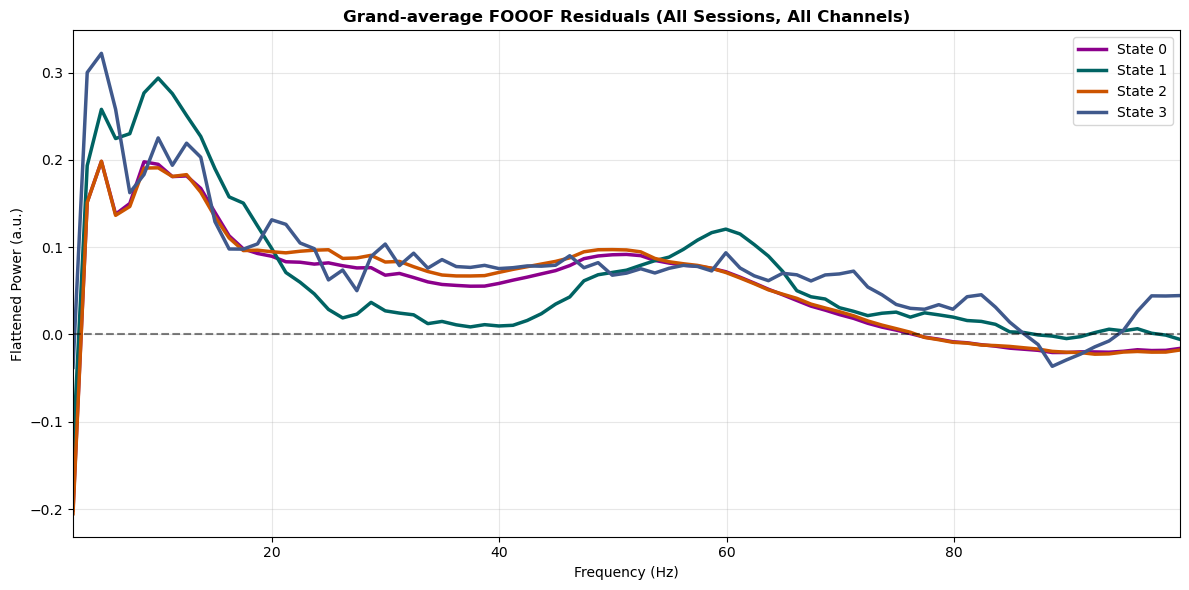


=== Done ===


In [ ]:
# -----------------------------
# Grand-average plotting (ALL sessions + ALL channels)
# -----------------------------

state_colors = {
    0: (0.55, 0.0, 0.55),   # purple
    1: (0.0, 0.39, 0.39),   # teal
    2: (0.8, 0.33, 0.0),    # orange
    3: (0.25, 0.35, 0.55)   # slate blue
}


def plot_grand_average_timelock(state_data_timelock):
    """
    Grand-average timelock across all sessions and channels.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for state_idx in range(N_STATES_TO_USE):
        all_trials = []
        time = None

        for (session_name, s_idx), data_list in state_data_timelock.items():
            if s_idx != state_idx or len(data_list) == 0:
                continue

            data = data_list[0]
            trials = data['trials']          # (n_trials, n_time, n_channels)
            time = data['time']

            trials_avg_ch = np.nanmean(trials, axis=2)  # avg over channels
            all_trials.append(trials_avg_ch)

        if len(all_trials) == 0:
            continue

        combined_trials = np.vstack(all_trials)  # (total_trials, n_time)

        mean_erp = np.nanmean(combined_trials, axis=0)
        sem_erp = np.nanstd(combined_trials, axis=0) / np.sqrt(
            np.sum(~np.isnan(combined_trials), axis=0)
        )

        ax.plot(time, mean_erp,
                color=state_colors[state_idx],
                linewidth=2.5,
                label=f'State {state_idx} (n={combined_trials.shape[0]})')

        ax.fill_between(time, mean_erp - sem_erp, mean_erp + sem_erp,
                        color=state_colors[state_idx], alpha=0.3)

    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title('Grand-average Timelock (All Sessions, All Channels)',
                 fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_grand_average_spectra(state_data_spectra):
    """
    Grand-average power spectra across all sessions and channels.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for state_idx in range(N_STATES_TO_USE):
        all_power = []
        freqs = None

        for (session_name, s_idx), data_list in state_data_spectra.items():
            if s_idx != state_idx or len(data_list) == 0:
                continue

            data = data_list[0]
            power = data['power']    # (n_trials, n_freqs, n_channels)
            freqs = data['freqs']

            power_avg_ch = np.nanmean(power, axis=2)  # avg over channels
            all_power.append(power_avg_ch)

        if len(all_power) == 0:
            continue

        combined_power = np.vstack(all_power)  # (total_trials, n_freqs)
        log_power = 10 * np.log10(combined_power)

        mean_power = np.nanmean(log_power, axis=0)
        sem_power = np.nanstd(log_power, axis=0) / np.sqrt(
            np.sum(~np.isnan(log_power), axis=0)
        )

        ax.plot(freqs, mean_power,
                color=state_colors[state_idx],
                linewidth=2.5,
                label=f'State {state_idx} (n={combined_power.shape[0]})')

        ax.fill_between(freqs, mean_power - sem_power, mean_power + sem_power,
                        color=state_colors[state_idx], alpha=0.3)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.set_title('Grand-average Power Spectrum (All Sessions, All Channels)',
                 fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([freqs[0], freqs[-1]])
    plt.tight_layout()
    plt.show()


def plot_grand_average_fooof_residuals(state_data_residuals):
    """
    Grand-average FOOOF residuals across all sessions and channels.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for state_idx in range(N_STATES_TO_USE):
        all_resid = []
        freqs = None

        for (session_name, s_idx), data_list in state_data_residuals.items():
            if s_idx != state_idx or len(data_list) == 0:
                continue

            data = data_list[0]
            residuals = data['residuals']  # (n_freqs, n_channels)
            freqs = data['freqs']

            resid_avg_ch = np.nanmean(residuals, axis=1)
            all_resid.append(resid_avg_ch)

        if len(all_resid) == 0:
            continue

        combined_resid = np.vstack(all_resid)
        mean_resid = np.nanmean(combined_resid, axis=0)

        ax.plot(freqs, mean_resid,
                color=state_colors[state_idx],
                linewidth=2.5,
                label=f'State {state_idx}')

    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Flattened Power (a.u.)')
    ax.set_title('Grand-average FOOOF Residuals (All Sessions, All Channels)',
                 fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim([freqs[0], freqs[-1]])
    plt.tight_layout()
    plt.show()


# -----------------------------
# Generate GRAND AVERAGE plots
# -----------------------------
plot_grand_average_timelock(state_data_timelock)
plot_grand_average_spectra(state_data_spectra)
plot_grand_average_fooof_residuals(state_data_residuals)


# Compare within states

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
BIN_SIZE = 0.25  # % range per bin, e.g., 0.25 for 25%
N_STATES_TO_USE = 4  # number of states
MIN_TRIALS_PER_BIN = 5  # skip bins with too few trials

# Create probability bins dynamically
PROB_BINS = [(i, i + BIN_SIZE) for i in np.arange(0, 1, BIN_SIZE)]
PROB_BIN_LABELS = [f"{int(low*100)}–{int(high*100)}%" for (low, high) in PROB_BINS]

# Colors for states
state_colors = {
    0: (0.55, 0.0, 0.55),
    1: (0.0, 0.39, 0.39),
    2: (0.8, 0.33, 0.0),
    3: (0.25, 0.35, 0.55)
}

# -----------------------------
# FUNCTIONS
# -----------------------------
def get_state_probability_bins(state_probs, prob_bins, n_states):
    """Return boolean masks for each state and probability bin"""
    bins = {}
    for state_idx in range(n_states):
        for bin_idx, (low, high) in enumerate(prob_bins):
            bins[(state_idx, bin_idx)] = (
                (state_probs[:, state_idx] >= low) &
                (state_probs[:, state_idx] < high)
            )
    return bins

# -----------------------------
# CONTAINERS
# -----------------------------
timelock_all = {}   # (state, bin) -> list of trials × time
spectra_all = {}    # (state, bin) -> list of trials × freq

time_ref = None
freqs_ref = None

# -----------------------------
# MAIN LOOP
# -----------------------------
for session_name in sessions:

    # State probabilities for this session
    predicted_state_probs = session_to_probs[session_name]

    # Load LFP data
    datalfp = spy.load(os.path.join(lfp_data_dir, session_name, 'Cleaned_lfp_FT.spy'))
    ensure_trialindex_in_trialdefinition(datalfp)
    data = spy.selectdata(spy.StructDict(latency=[-0.2, 0.6]), datalfp)

    # Align trials
    selected_trials = data.trialdefinition[:, 3].astype(int)
    state_probs_array = predicted_state_probs[selected_trials, :N_STATES_TO_USE]

    # Get bins
    state_prob_bins = get_state_probability_bins(state_probs_array, PROB_BINS, N_STATES_TO_USE)

    for (state_idx, bin_idx), mask in state_prob_bins.items():
        if np.sum(mask) < MIN_TRIALS_PER_BIN:
            continue  # skip small bins

        trial_idx = np.where(mask)[0]
        datas_sel = spy.selectdata(spy.StructDict(trials=trial_idx), data)
        datas_clean, _ = remove_nan_trials_channels(datas_sel)
        if datas_clean is None or not datas_clean.trials:
            continue

        # ---------- TIMELOCK ----------
        trials = np.stack(datas_clean.trials, axis=0)  # trials × time × ch
        trials_avg_ch = np.nanmean(trials, axis=2)     # trials × time
        time_ref = datas_clean.time[0]
        timelock_all.setdefault((state_idx, bin_idx), []).append(trials_avg_ch)

        # ---------- SPECTRA ----------
        cfg_fft = spy.StructDict(method='mtmfft', foilim=[2, 40],
                                 out='pow', keeptrials=True, taper='hann')
        freq = spy.freqanalysis(datas_clean, cfg_fft)
        power, freqs, _ = extract_power_trials(freq)

        # Skip if no power data
        if power is None or power.size == 0 or power.ndim != 3:
            continue

        power_avg_ch = np.nanmean(power, axis=2)  # trials × freq
        freqs_ref = freqs
        spectra_all.setdefault((state_idx, bin_idx), []).append(power_avg_ch)


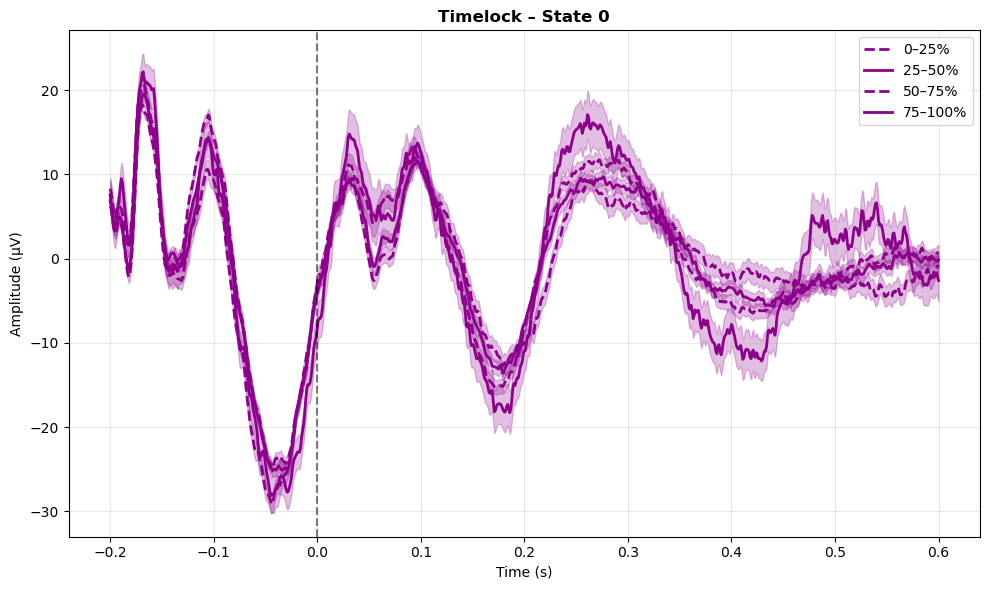

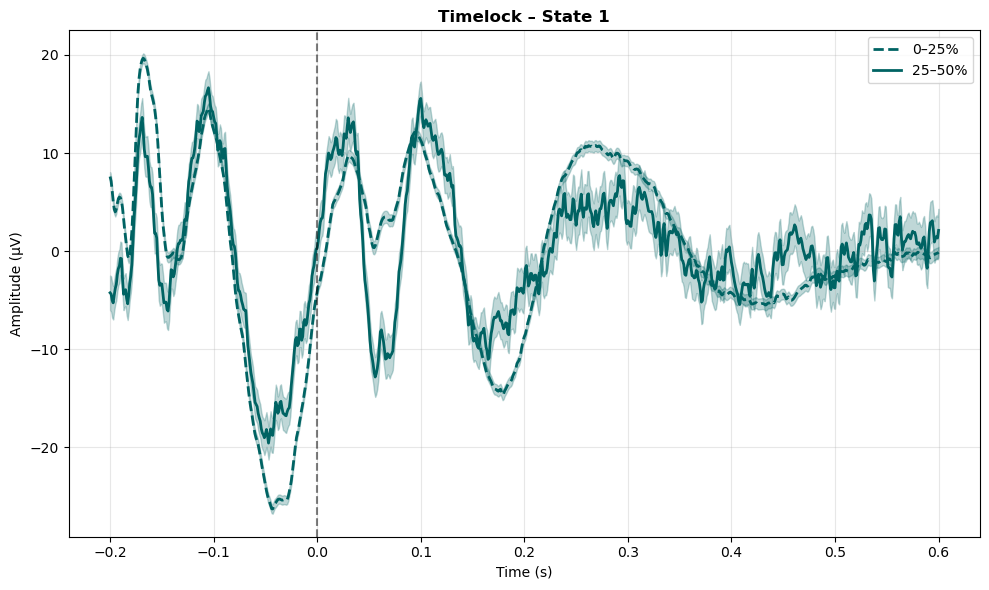

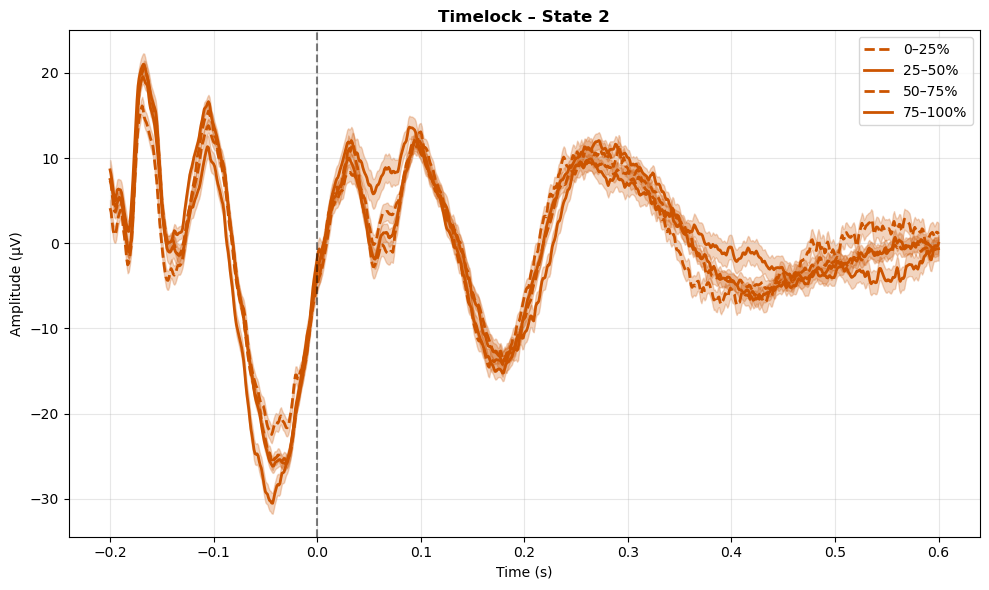

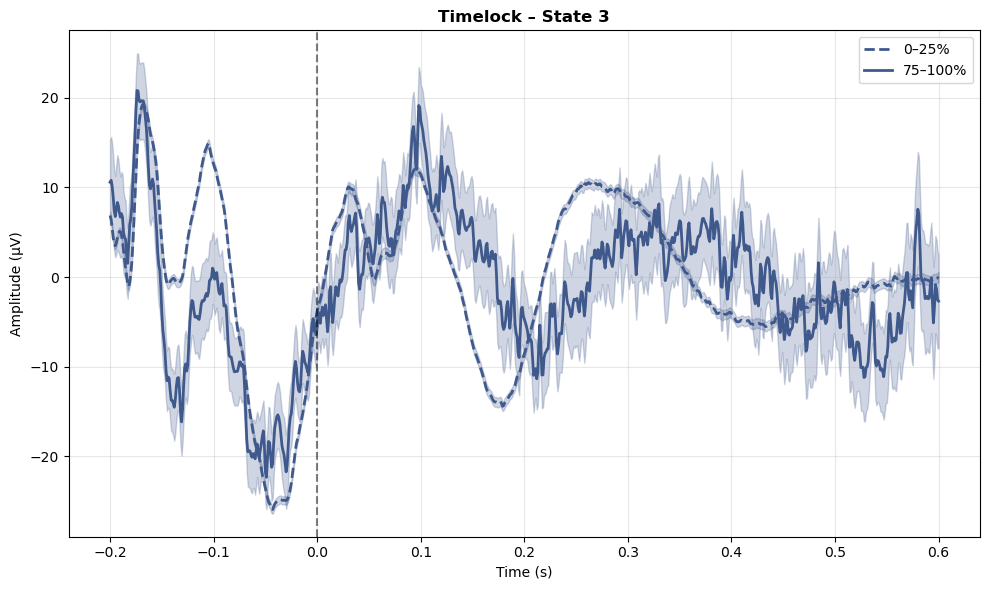

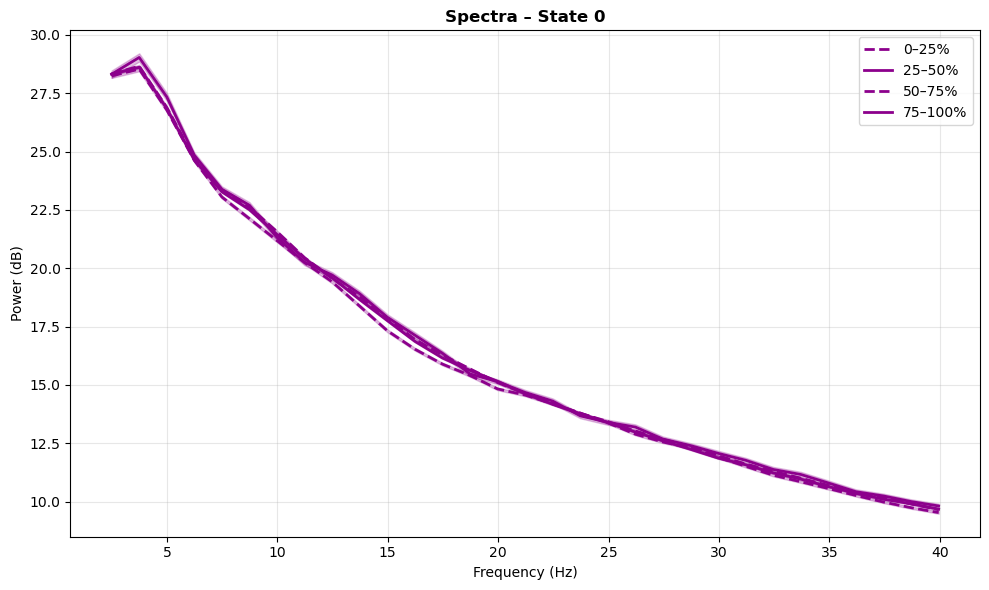

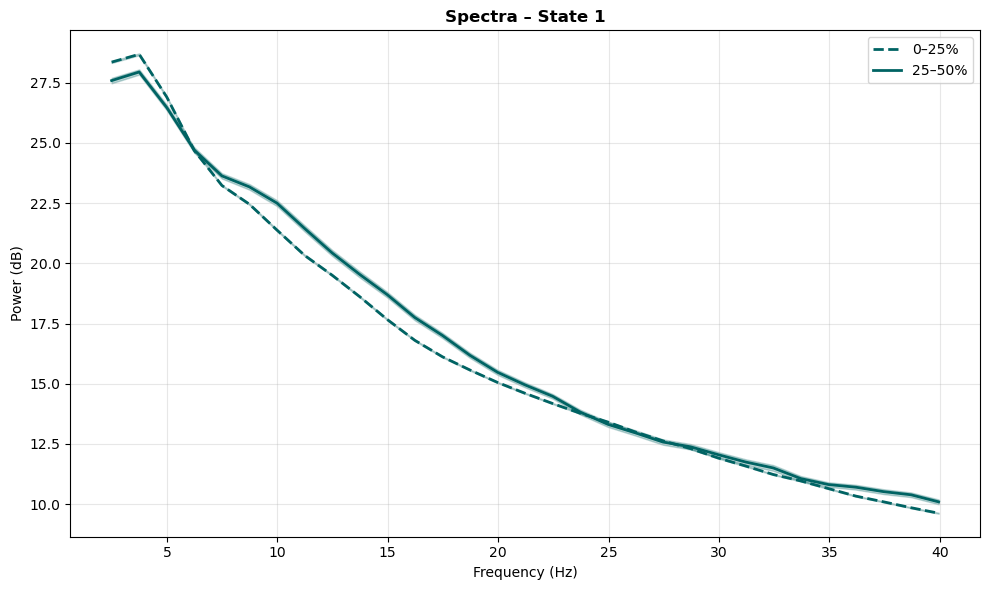

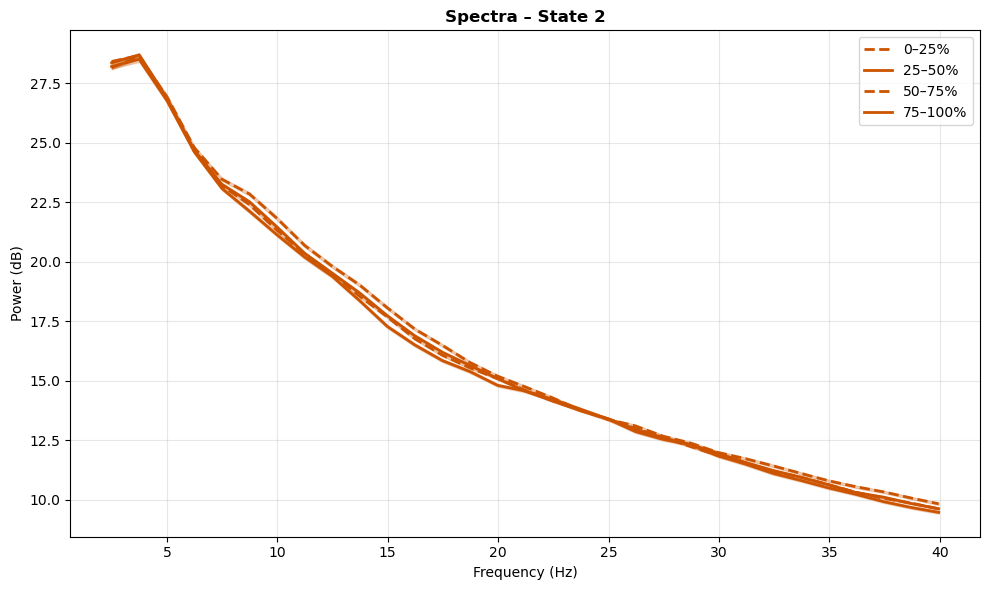

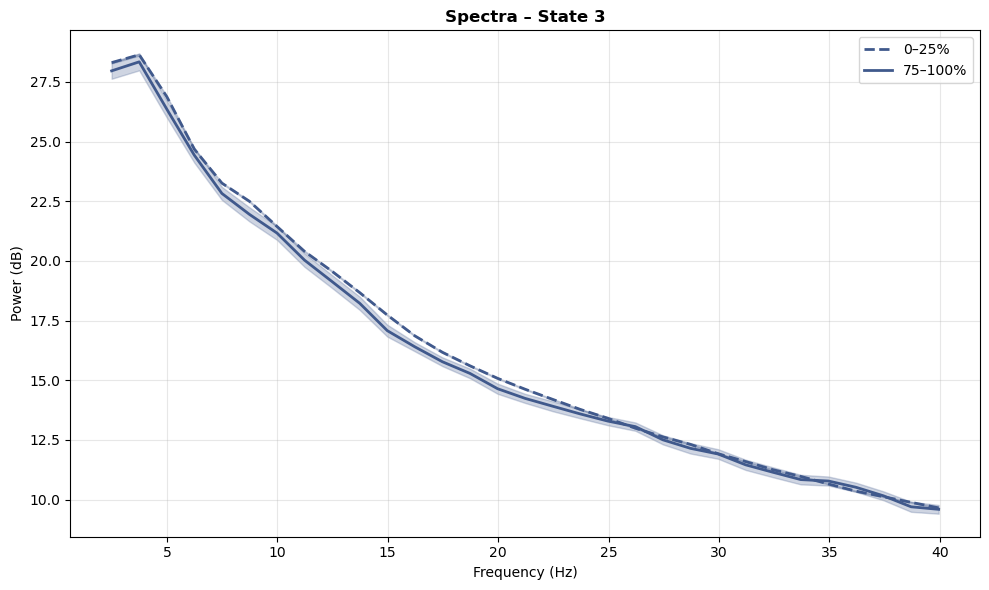

In [25]:

# -----------------------------
# PLOT: TIMELOCK (one state per plot)
# -----------------------------
for state_idx in range(N_STATES_TO_USE):
    plt.figure(figsize=(10, 6))
    has_data = False
    for bin_idx in range(len(PROB_BINS)):
        key = (state_idx, bin_idx)
        if key not in timelock_all:
            continue
        has_data = True
        trials_list = timelock_all[key]
        trials = np.concatenate(trials_list, axis=0)
        mean = np.nanmean(trials, axis=0)
        sem = np.nanstd(trials, axis=0) / np.sqrt(trials.shape[0])
        color = state_colors[state_idx]
        linestyle = '--' if bin_idx % 2 == 0 else '-'
        label = f"{PROB_BIN_LABELS[bin_idx]}"
        plt.plot(time_ref, mean, color=color, linestyle=linestyle, linewidth=2, label=label)
        plt.fill_between(time_ref, mean - sem, mean + sem, color=color, alpha=0.25)
    if has_data:
        plt.axvline(0, color='k', linestyle='--', alpha=0.5)
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (µV)')
        plt.title(f'Timelock – State {state_idx}', fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

# -----------------------------
# PLOT: SPECTRA (one state per plot)
# -----------------------------
for state_idx in range(N_STATES_TO_USE):
    plt.figure(figsize=(10, 6))
    has_data = False
    for bin_idx in range(len(PROB_BINS)):
        key = (state_idx, bin_idx)
        if key not in spectra_all:
            continue
        has_data = True
        power_list = spectra_all[key]
        power = np.concatenate(power_list, axis=0)
        log_power = 10 * np.log10(power)
        mean = np.nanmean(log_power, axis=0)
        sem = np.nanstd(log_power, axis=0) / np.sqrt(log_power.shape[0])
        color = state_colors[state_idx]
        linestyle = '--' if bin_idx % 2 == 0 else '-'
        label = f"{PROB_BIN_LABELS[bin_idx]}"
        plt.plot(freqs_ref, mean, color=color, linestyle=linestyle, linewidth=2, label=label)
        plt.fill_between(freqs_ref, mean - sem, mean + sem, color=color, alpha=0.25)
    if has_data:
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (dB)')
        plt.title(f'Spectra – State {state_idx}', fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


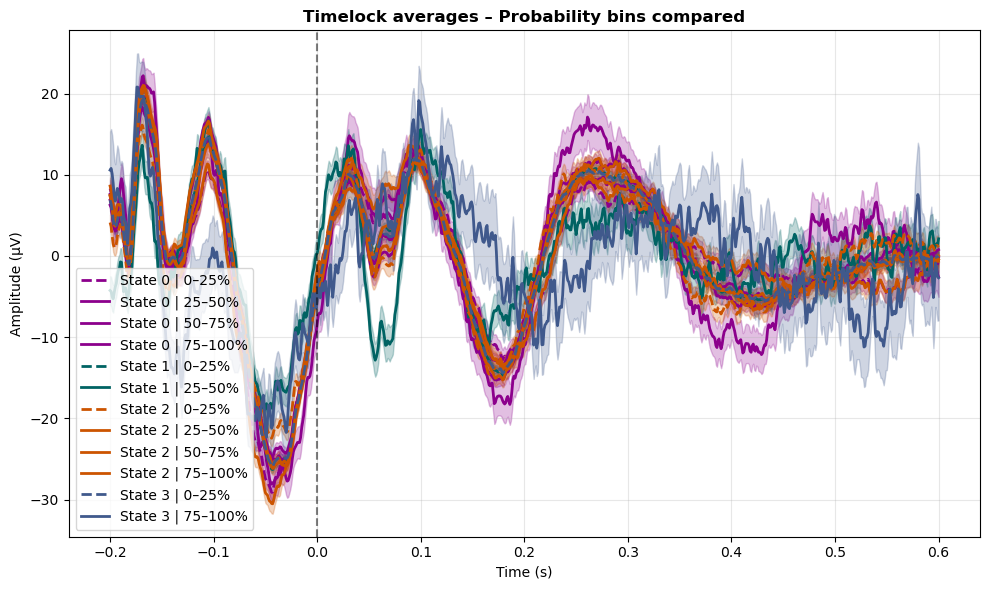

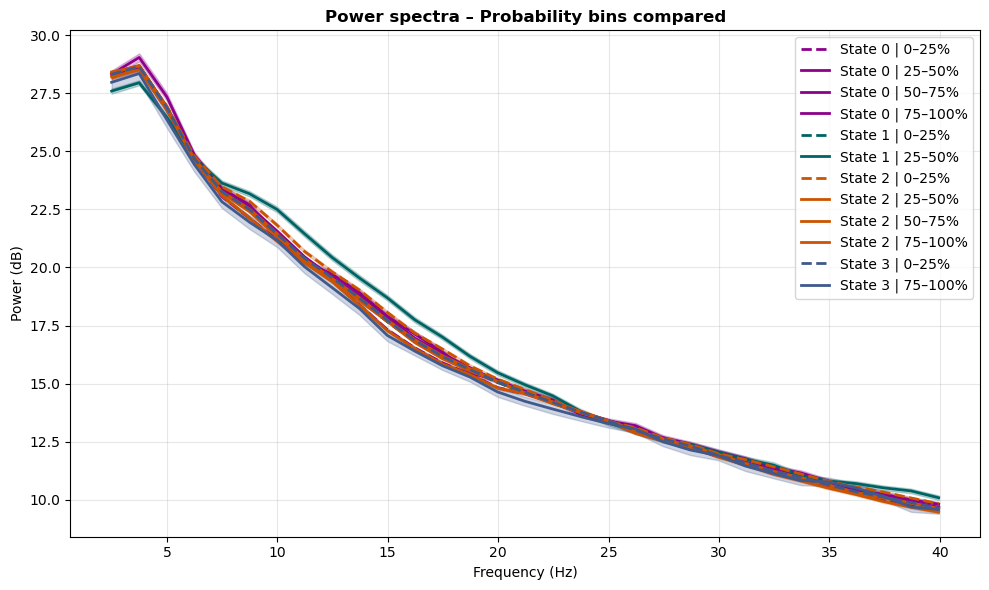

In [26]:
# -----------------------------
# Plot: Timelock – compare probability bins in same plot
# -----------------------------
plt.figure(figsize=(10, 6))

for state_idx in range(N_STATES_TO_USE):
    for bin_idx, bin_label in enumerate(PROB_BIN_LABELS):
        key = (state_idx, bin_idx)
        if key not in timelock_all:
            continue

        # Concatenate all trials across sessions
        trials_list = timelock_all[key]
        trials = np.concatenate(trials_list, axis=0)

        mean = np.nanmean(trials, axis=0)
        sem = np.nanstd(trials, axis=0) / np.sqrt(trials.shape[0])

        color = state_colors[state_idx]
        linestyle = '--' if bin_idx == 0 else '-'  # dashed for 0-50%, solid for 50-100%

        label = f"State {state_idx} | {bin_label}"
        plt.plot(time_ref, mean, color=color, linestyle=linestyle, linewidth=2, label=label)
        plt.fill_between(time_ref, mean - sem, mean + sem, color=color, alpha=0.25)

plt.axvline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('Timelock averages – Probability bins compared', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Plot: Spectra – compare probability bins in same plot
# -----------------------------
plt.figure(figsize=(10, 6))

for state_idx in range(N_STATES_TO_USE):
    for bin_idx, bin_label in enumerate(PROB_BIN_LABELS):
        key = (state_idx, bin_idx)
        if key not in spectra_all:
            continue

        # Concatenate all trials across sessions
        power_list = spectra_all[key]
        power = np.concatenate(power_list, axis=0)

        log_power = 10 * np.log10(power)
        mean = np.nanmean(log_power, axis=0)
        sem = np.nanstd(log_power, axis=0) / np.sqrt(log_power.shape[0])

        color = state_colors[state_idx]
        linestyle = '--' if bin_idx == 0 else '-'  # dashed for 0-50%, solid for 50-100%

        label = f"State {state_idx} | {bin_label}"
        plt.plot(freqs_ref, mean, color=color, linestyle=linestyle, linewidth=2, label=label)
        plt.fill_between(freqs_ref, mean - sem, mean + sem, color=color, alpha=0.25)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title('Power spectra – Probability bins compared', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


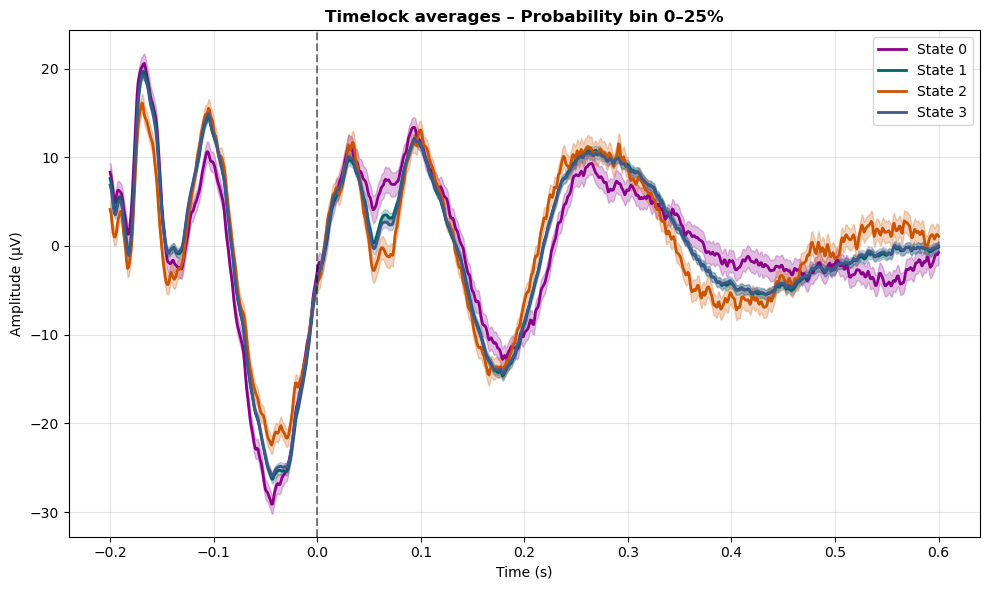

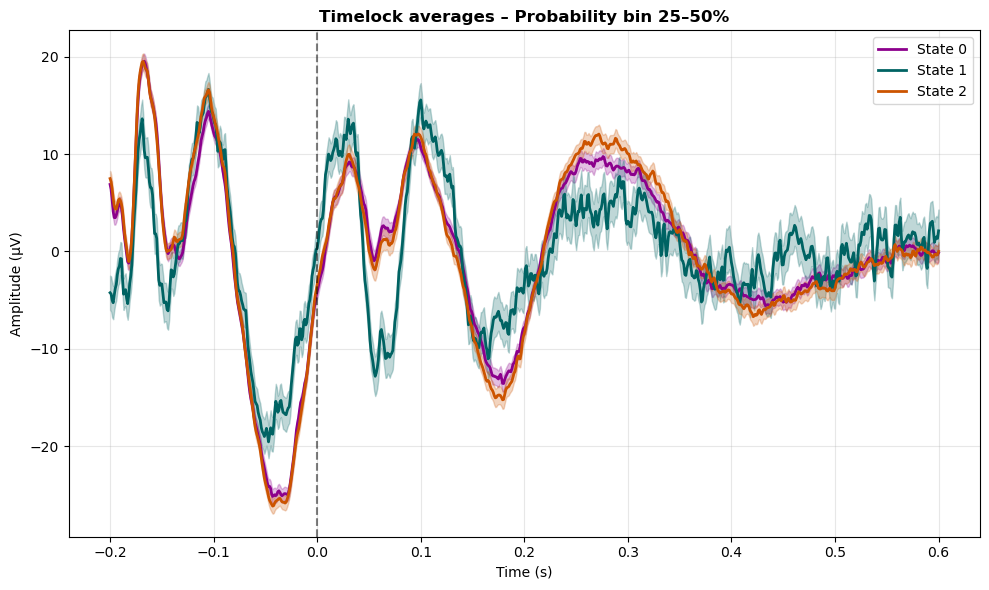

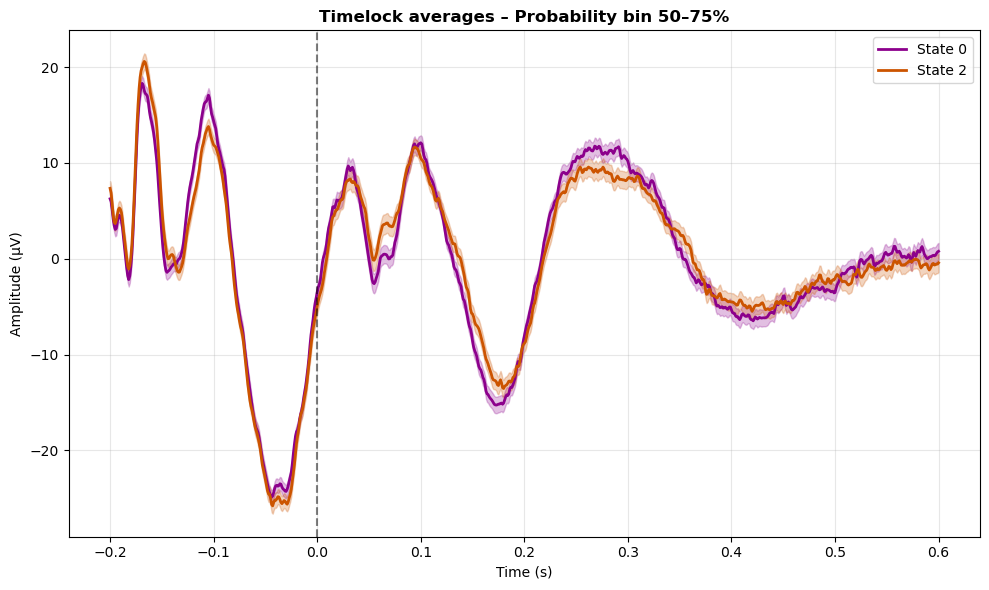

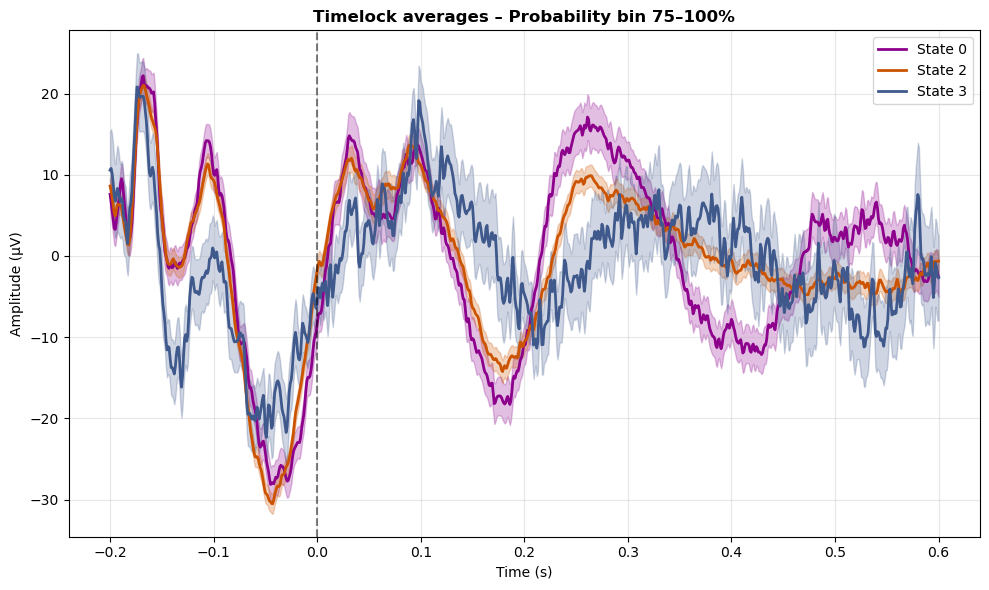

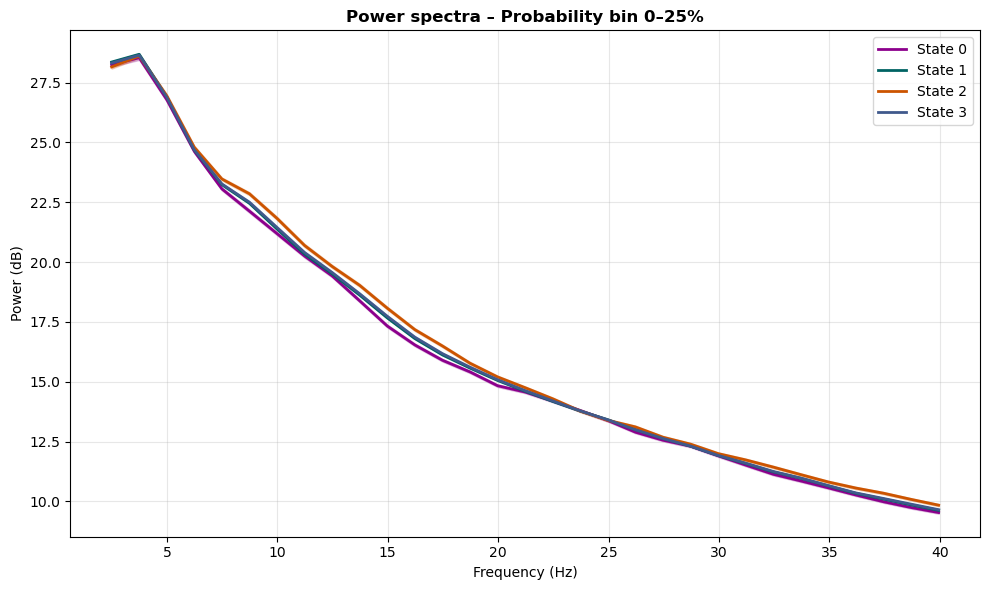

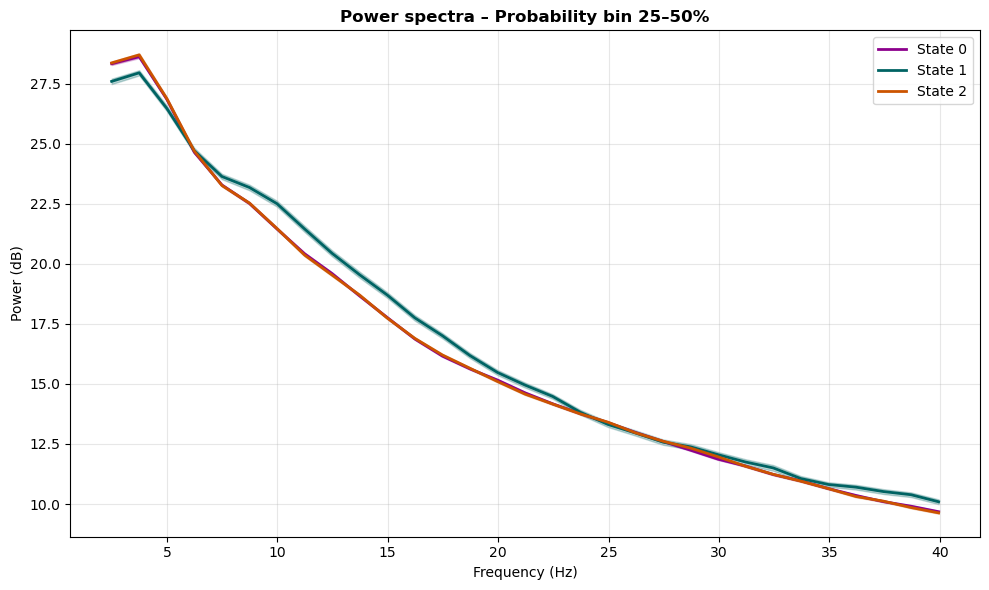

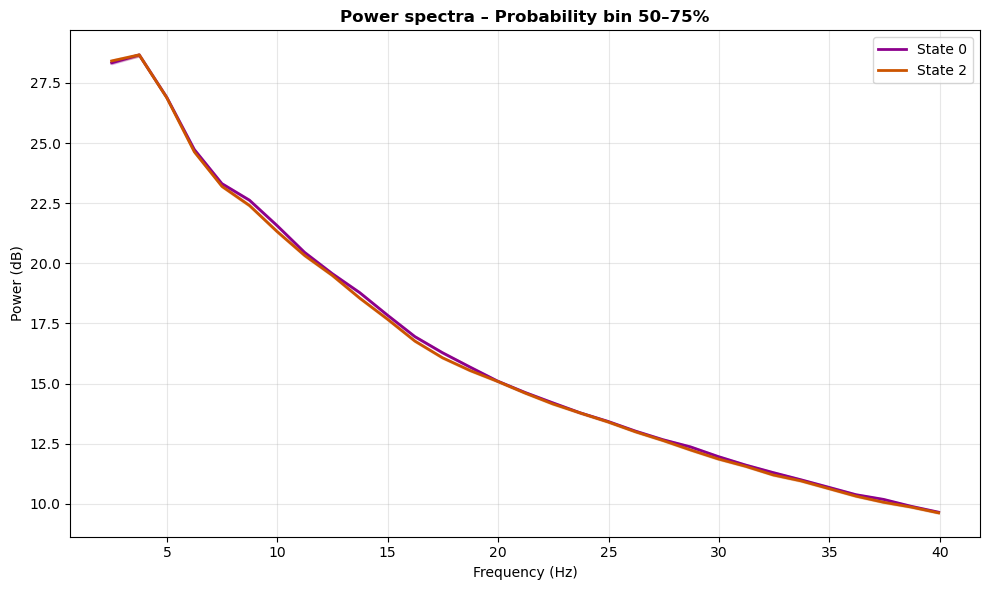

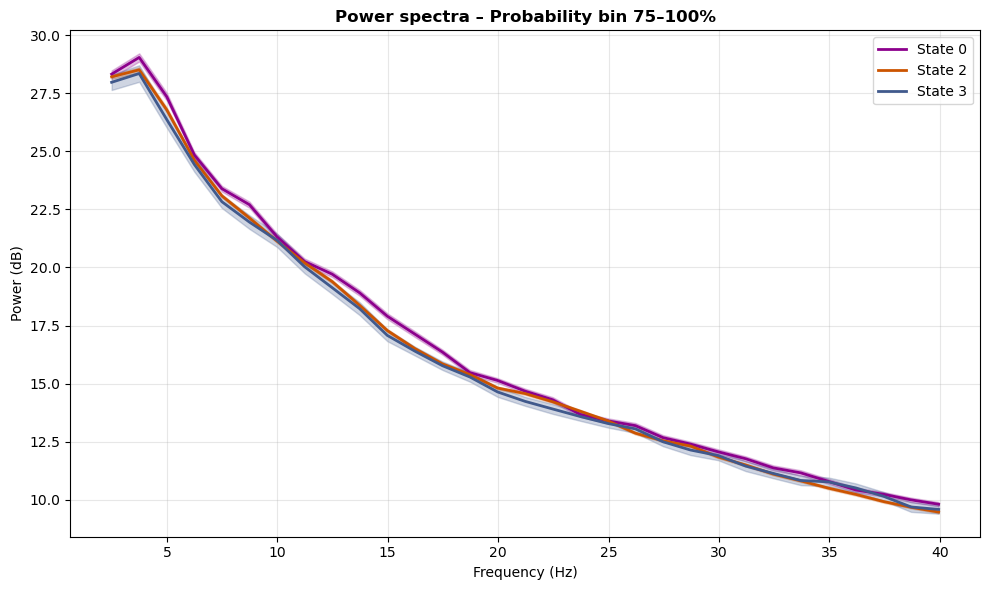

In [27]:
# -----------------------------
# Plot: Timelock per probability bin
# -----------------------------
for bin_idx, bin_label in enumerate(PROB_BIN_LABELS):
    plt.figure(figsize=(10, 6))
    for state_idx in range(N_STATES_TO_USE):
        key = (state_idx, bin_idx)
        if key not in timelock_all:
            continue
        
        # Concatenate all trials across sessions
        trials_list = timelock_all[key]
        trials = np.concatenate(trials_list, axis=0)
        
        mean = np.nanmean(trials, axis=0)
        sem = np.nanstd(trials, axis=0) / np.sqrt(trials.shape[0])
        
        color = state_colors[state_idx]
        plt.plot(time_ref, mean, color=color, linewidth=2, label=f"State {state_idx}")
        plt.fill_between(time_ref, mean - sem, mean + sem, color=color, alpha=0.25)
    
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (µV)')
    plt.title(f'Timelock averages – Probability bin {bin_label}', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Plot: Spectra per probability bin
# -----------------------------
for bin_idx, bin_label in enumerate(PROB_BIN_LABELS):
    plt.figure(figsize=(10, 6))
    for state_idx in range(N_STATES_TO_USE):
        key = (state_idx, bin_idx)
        if key not in spectra_all:
            continue
        
        # Concatenate all trials across sessions
        power_list = spectra_all[key]
        power = np.concatenate(power_list, axis=0)
        
        log_power = 10 * np.log10(power)
        mean = np.nanmean(log_power, axis=0)
        sem = np.nanstd(log_power, axis=0) / np.sqrt(log_power.shape[0])
        
        color = state_colors[state_idx]
        plt.plot(freqs_ref, mean, color=color, linewidth=2, label=f"State {state_idx}")
        plt.fill_between(freqs_ref, mean - sem, mean + sem, color=color, alpha=0.25)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (dB)')
    plt.title(f'Power spectra – Probability bin {bin_label}', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# State probability weighted neural data averages

In [ ]:
import numpy as np
import os
import pandas as pd
from fooof import FOOOF

N_STATES_TO_USE = 4

state_data_timelock = {}
state_data_spectra = {}
state_data_residuals = {}


In [20]:
def confidence_weighted_mean(data, weights):
    """
    Generic confidence-weighted mean.

    data    : ndarray (trials × ...)
    weights : ndarray (trials,)

    Returns
    -------
    weighted_mean : ndarray (...)
    """
    if np.nansum(weights) == 0:
        return None

    w = weights.reshape((-1,) + (1,) * (data.ndim - 1))
    return np.nansum(data * w, axis=0) / np.nansum(weights)

def effective_n_trials(weights):
    """
    Effective sample size for weighted averages.
    """
    return (np.sum(weights) ** 2) / np.sum(weights ** 2)


In [ ]:
# -----------------------------
# MAIN LOOP (Confidence-Weighted)
# -----------------------------
for session_name in sessions:

    print(f"\n=== Processing session {session_name} ===")

    # -----------------------------
    # Load state probabilities
    # -----------------------------
    predicted_state_probs = session_to_probs[session_name]  # (all_trials × n_states)

    # -----------------------------
    # Load LFP data
    # -----------------------------
    lfp_path = os.path.join(lfp_data_dir, session_name, 'Cleaned_lfp_FT.spy')
    datalfp = spy.load(lfp_path)
    ensure_trialindex_in_trialdefinition(datalfp)

    data = spy.selectdata(spy.StructDict(latency=[-0.2, 0.6]), datalfp)

    # Align trials
    selected_trials = data.trialdefinition[:, 3].astype(int)
    state_probs_array = predicted_state_probs[selected_trials, :N_STATES_TO_USE]

    # -----------------------------
    # Remove NaN trials and channels (keep partially valid trials)
    # -----------------------------
    def remove_nan_trials_channels_keep_partial(datas):
        """
        Removes trials that are fully NaN and channels that are fully NaN.
        Returns:
            datas_clean
            valid_channels
            kept_trial_idx  # integer indices relative to original datas.trials
        """
        trial_mask = [not np.all(np.isnan(tr)) for tr in datas.trials]
        if not any(trial_mask):
            return None, [], []

        kept_trial_idx = np.where(trial_mask)[0]
        cfg = spy.StructDict(trials=kept_trial_idx)
        datas_clean = spy.selectdata(cfg, datas)

        trial_stack = np.stack(datas_clean.trials, axis=0)
        valid_ch_idx = np.where(~np.all(np.isnan(trial_stack), axis=(0, 1)))[0]
        if len(valid_ch_idx) == 0:
            return None, [], []

        cfg = spy.StructDict(channel=valid_ch_idx)
        datas_clean = spy.selectdata(cfg, datas_clean)
        valid_channels = [datas.channel[i] for i in valid_ch_idx]

        return datas_clean, valid_channels, kept_trial_idx

    datas_clean, valid_channels, kept_trial_idx = remove_nan_trials_channels_keep_partial(data)

    if datas_clean is None:
        print("  No valid trials after NaN removal")
        continue

    # Apply original trial indices to state probabilities
    state_probs_array = state_probs_array[kept_trial_idx, :]
    trials_array = np.stack(datas_clean.trials, axis=0)  # trials × time × ch
    time_vec = datas_clean.time[0]

    # -----------------------------
    # SPECTRA
    # -----------------------------
    cfg_fft = spy.StructDict(
        method='mtmfft',
        foilim=[2, 100],
        out='pow',
        keeptrials=True,
        taper='hann'
    )
    freq = spy.freqanalysis(datas_clean, cfg_fft)
    power, freqs, channels = extract_power_trials(freq)
    if power is None:
        print("  No spectral data")
        continue

    # -----------------------------
    # PER-STATE ANALYSIS
    # -----------------------------
    for state_idx in range(N_STATES_TO_USE):

        weights = state_probs_array[:, state_idx]
        n_eff = effective_n_trials(weights)

        if n_eff < MIN_TRIALS_PER_BIN:
            print(f"  State {state_idx}: skipped (n_eff={n_eff:.1f})")
            continue

        print(f"  State {state_idx}: n_eff={n_eff:.1f}")

        # ========= TIMELOCK =========
        weighted_timelock = confidence_weighted_mean(trials_array, weights)  # time × ch
        timelock_avg_ch = np.nanmean(weighted_timelock, axis=1)

        state_data_timelock.setdefault((session_name, state_idx), []).append({
            'timelock': weighted_timelock,
            'timelock_avg_ch': timelock_avg_ch,
            'time': time_vec,
            'channels': valid_channels,
            'n_eff': n_eff
        })

        # ========= SPECTRA =========
        weighted_spectrum = confidence_weighted_mean(power, weights)  # freq × ch

        state_data_spectra.setdefault((session_name, state_idx), []).append({
            'spectrum': weighted_spectrum,
            'freqs': freqs,
            'channels': channels,
            'n_eff': n_eff
        })

        # ========= FOOOF =========
        resid = np.full_like(weighted_spectrum, np.nan)
        freq_res = np.median(np.diff(freqs))

        for ch_i, ch_name in enumerate(valid_channels):
            try:
                fm = FOOOF(
                    peak_width_limits=[max(2 * freq_res, 1.0), 12],
                    max_n_peaks=6,
                    min_peak_height=0.05,
                    peak_threshold=1.5,
                    aperiodic_mode='fixed'
                )
                fm.fit(freqs, weighted_spectrum[:, ch_i])
                resid[:, ch_i] = fm._spectrum_flat
            except Exception as e:
                print(f"FOOOF failed {session_name}, State {state_idx}, ch {ch_name}")

        state_data_residuals.setdefault((session_name, state_idx), []).append({
            'residuals': resid,
            'freqs': freqs,
            'channels': valid_channels,
            'n_eff': n_eff
        })



=== Processing session 20230203 ===
  State 0: n_eff=897.2
  State 1: n_eff=361.5
  State 2: n_eff=844.8
  State 3: n_eff=23.1

=== Processing session 20230208 ===
  State 0: n_eff=682.1
  State 1: n_eff=257.6
  State 2: n_eff=741.8
  State 3: n_eff=30.4

=== Processing session 20230209 ===
  State 0: n_eff=756.8
  State 1: n_eff=296.6
  State 2: n_eff=712.7
  State 3: n_eff=12.5

=== Processing session 20230213 ===
  State 0: n_eff=867.3
  State 1: n_eff=346.2
  State 2: n_eff=801.0
  State 3: n_eff=20.0

=== Processing session 20230214 ===
  State 0: n_eff=791.0
  State 1: n_eff=308.9
  State 2: n_eff=755.0
  State 3: n_eff=7.8


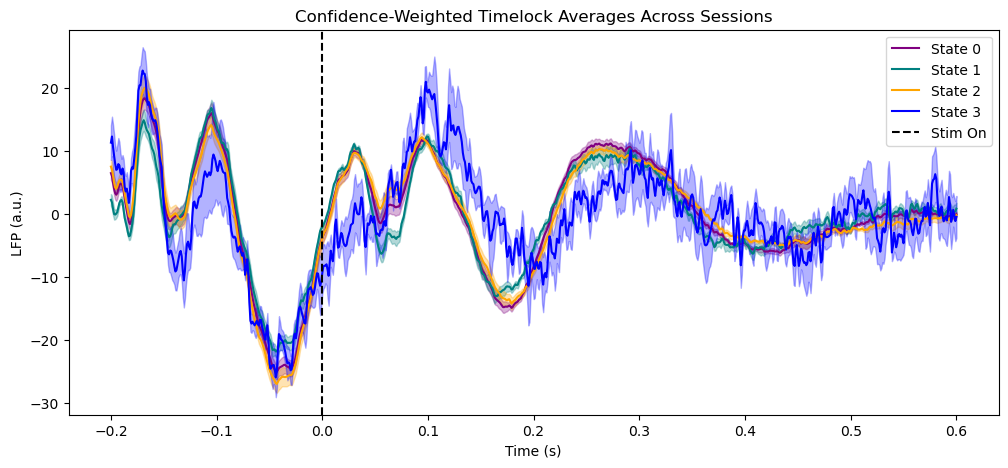

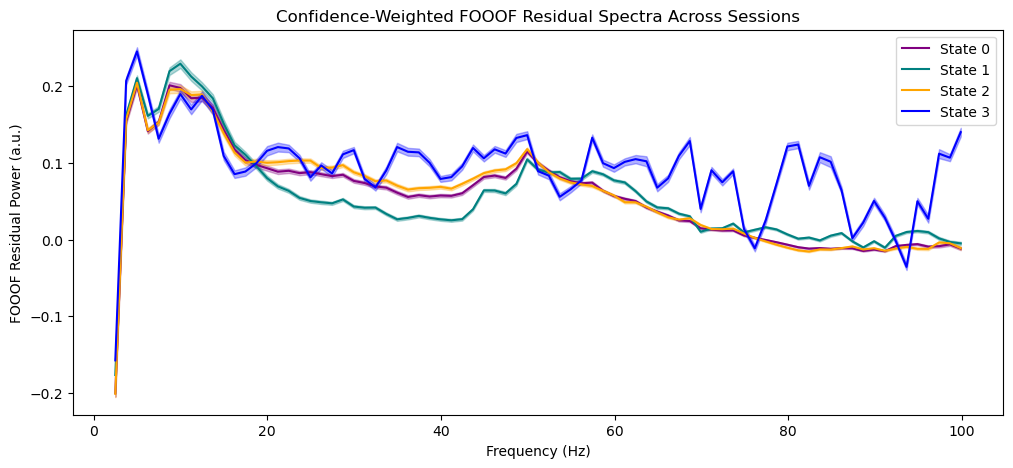

In [24]:
# -----------------------------
# PARAMETERS
# -----------------------------
states_to_plot = range(N_STATES_TO_USE)
colors = ['purple', 'teal', 'orange', 'blue']  # match your state_colors

# -----------------------------
# PLOT: TIMELOCK AVERAGES
# -----------------------------
plt.figure(figsize=(12, 5))
for state_idx in states_to_plot:
    # Collect all trials × time across sessions for this state
    all_timelock = []
    for key, entries in state_data_timelock.items():
        sess, s_idx = key
        if s_idx != state_idx:
            continue
        for entry in entries:
            all_timelock.append(entry['timelock_avg_ch'])  # trials × time averaged over channels

    if not all_timelock:
        continue

    all_timelock = np.vstack(all_timelock)  # stack trials × time
    mean_timelock = np.nanmean(all_timelock, axis=0)
    sem_timelock = np.nanstd(all_timelock, axis=0) / np.sqrt(all_timelock.shape[0])

    # Use time from first entry
    time_vec = entries[0]['time']

    plt.plot(time_vec, mean_timelock, color=colors[state_idx], label=f"State {state_idx}")
    plt.fill_between(time_vec, mean_timelock - sem_timelock, mean_timelock + sem_timelock,
                     color=colors[state_idx], alpha=0.3)

plt.axvline(0, color='k', linestyle='--', label='Stim On')
plt.xlabel("Time (s)")
plt.ylabel("LFP (a.u.)")
plt.title("Confidence-Weighted Timelock Averages Across Sessions")
plt.legend()
plt.show()


# -----------------------------
# PLOT: FOOOF RESIDUALS (Power Spectra)
# -----------------------------
plt.figure(figsize=(12, 5))
for state_idx in states_to_plot:
    # Collect all residuals × freq across sessions for this state
    all_resid = []
    for key, entries in state_data_residuals.items():
        sess, s_idx = key
        if s_idx != state_idx:
            continue
        for entry in entries:
            all_resid.append(entry['residuals'])  # freq × ch

    if not all_resid:
        continue

    # Concatenate along channels across sessions
    all_resid_concat = np.concatenate(all_resid, axis=1)  # freq × total_channels
    mean_resid = np.nanmean(all_resid_concat, axis=1)
    sem_resid = np.nanstd(all_resid_concat, axis=1) / np.sqrt(all_resid_concat.shape[1])

    freqs = entries[0]['freqs']

    plt.plot(freqs, mean_resid, color=colors[state_idx], label=f"State {state_idx}")
    plt.fill_between(freqs, mean_resid - sem_resid, mean_resid + sem_resid,
                     color=colors[state_idx], alpha=0.3)

plt.xlabel("Frequency (Hz)")
plt.ylabel("FOOOF Residual Power (a.u.)")
plt.title("Confidence-Weighted FOOOF Residual Spectra Across Sessions")
plt.legend()
plt.show()


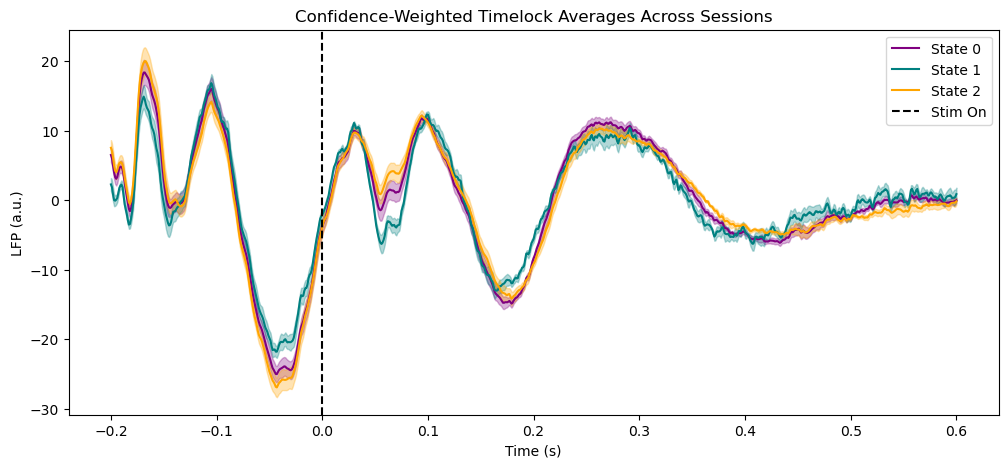

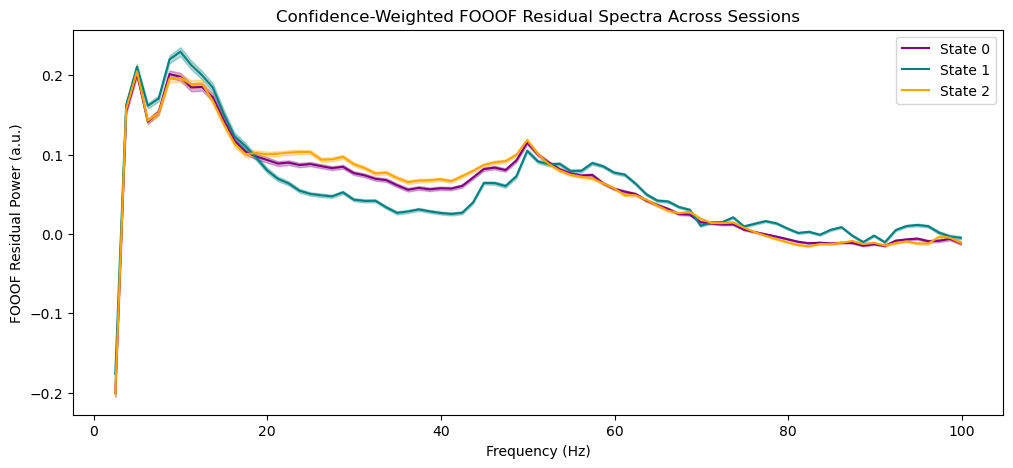

In [25]:
# -----------------------------
# PARAMETERS
# -----------------------------
states_to_plot = range(3)
colors = ['purple', 'teal', 'orange']

# -----------------------------
# PLOT: TIMELOCK AVERAGES
# -----------------------------
plt.figure(figsize=(12, 5))
for state_idx in states_to_plot:
    # Collect all trials × time across sessions for this state
    all_timelock = []
    for key, entries in state_data_timelock.items():
        sess, s_idx = key
        if s_idx != state_idx:
            continue
        for entry in entries:
            all_timelock.append(entry['timelock_avg_ch'])  # trials × time averaged over channels

    if not all_timelock:
        continue

    all_timelock = np.vstack(all_timelock)  # stack trials × time
    mean_timelock = np.nanmean(all_timelock, axis=0)
    sem_timelock = np.nanstd(all_timelock, axis=0) / np.sqrt(all_timelock.shape[0])

    # Use time from first entry
    time_vec = entries[0]['time']

    plt.plot(time_vec, mean_timelock, color=colors[state_idx], label=f"State {state_idx}")
    plt.fill_between(time_vec, mean_timelock - sem_timelock, mean_timelock + sem_timelock,
                     color=colors[state_idx], alpha=0.3)

plt.axvline(0, color='k', linestyle='--', label='Stim On')
plt.xlabel("Time (s)")
plt.ylabel("LFP (a.u.)")
plt.title("Confidence-Weighted Timelock Averages Across Sessions")
plt.legend()
plt.show()


# -----------------------------
# PLOT: FOOOF RESIDUALS (Power Spectra)
# -----------------------------
plt.figure(figsize=(12, 5))
for state_idx in states_to_plot:
    # Collect all residuals × freq across sessions for this state
    all_resid = []
    for key, entries in state_data_residuals.items():
        sess, s_idx = key
        if s_idx != state_idx:
            continue
        for entry in entries:
            all_resid.append(entry['residuals'])  # freq × ch

    if not all_resid:
        continue

    # Concatenate along channels across sessions
    all_resid_concat = np.concatenate(all_resid, axis=1)  # freq × total_channels
    mean_resid = np.nanmean(all_resid_concat, axis=1)
    sem_resid = np.nanstd(all_resid_concat, axis=1) / np.sqrt(all_resid_concat.shape[1])

    freqs = entries[0]['freqs']

    plt.plot(freqs, mean_resid, color=colors[state_idx], label=f"State {state_idx}")
    plt.fill_between(freqs, mean_resid - sem_resid, mean_resid + sem_resid,
                     color=colors[state_idx], alpha=0.3)

plt.xlabel("Frequency (Hz)")
plt.ylabel("FOOOF Residual Power (a.u.)")
plt.title("Confidence-Weighted FOOOF Residual Spectra Across Sessions")
plt.legend()
plt.show()
